# Planetary composites: AE versus CE, surface-referenced tilt
This extends `composite_breakdown` without changing it. Every selected day is translated to its fitted surface centre; the mean constituent centre at depth defines the new **surface-to-depth tilt vector**. Its length is the composite tilt distance. This definition also works for individual profiles; compositing estimates its population mean and can cancel opposing tilts. The length of the mean vector is **not** the mean length of individual vectors.

Geographic east/north components use the same ROMS grid-angle rotation as `seacofs_tilt_tools`. Bearings point **towards the deeper centre**, clockwise from north. They are reversed relative to the previous deep-to-shallow tilt convention. Existing `TiltDis` and `TiltDir` are never used to select or measure these tilts.

The main comparison includes all available fitted depths, including beyond 1,000 m. Independent depth support, whole-eddy bootstrap intervals, and a fixed-membership check accompany it. Intervals describe sampling uncertainty, not ESP fitting error or dependence between distinct eddies.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE = Path.cwd().resolve()
ANALYSIS = next((p for p in (HERE, *HERE.parents) if (p/'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subdirectory')
WORK = ANALYSIS/'esp_population_composites'
for p in (ANALYSIS, WORK):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
ESP_ROOT = Path("/home/z5297792/ESP_zonodo")
if str(ESP_ROOT) not in sys.path:
    sys.path.insert(0, str(ESP_ROOT))
import functions as esp
import seacofs_tilt_tools as tilt
pd.set_option('display.max_columns', 60)

# Reuse the dataset's directional-radius helper for the full composite refit.
DATASET_SRC = ANALYSIS.parent/'seacofs_eddy_dataset_modular'/'src'
if str(DATASET_SRC) not in sys.path:
    sys.path.insert(0, str(DATASET_SRC))
import composite_breakdown_tools as cbt

import planetary_composite_tools as pct

import composite_comparison_tools as ccomp


In [2]:
DOMINANCE_FACTOR = 2.0
ELLIPSE_FRAC = 1.0
MIN_PLAN_DEPTH_M = 3000.0
USE_PV_CACHE = True
SPLIT_DEPTH_M = 1000.0
TARGET_DEPTHS_M = [200., 500., 1000., 1500., 2000.]
BOOTSTRAPS = 500
SEED = 731
MIN_DIRECTION_DISTANCE_KM = 0.0  # zero vectors always have undefined direction
MIN_PLOT_EDDIES = 2  # plotting threshold only; all estimates remain in tables
WIDTH_KM, RES_KM = 400., 10.
RUN_VELOCITY_COMPOSITES = True
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
surface, _ = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
surface = tilt.add_pv_gradient_terms(surface, grid, core_mean=True, frac=ELLIPSE_FRAC,
    surface_method='esp_gaussian', averaging='nonlinear', use_cache=USE_PV_CACHE)
vertical = tilt.load_vert(paths)
planetary = surface.loc[(surface.topo_plan_ratio <= -np.log(DOMINANCE_FACTOR)) &
    (surface.h >= MIN_PLAN_DEPTH_M) & surface.Cyc.isin(['AE','CE'])].copy()
profile_audit, centred_profiles = pct.prepare_profiles(planetary, vertical, SPLIT_DEPTH_M)
display(profile_audit.groupby(['Cyc','profile_status'], dropna=False).size().rename('eddy_days'))
display(profile_audit.groupby(['Cyc','extent_group'],dropna=False).agg(
    eddy_days=('Day','size'), eddies=('Eddy','nunique'), median_max_depth=('max_fit_depth_m','median')))


Cyc  profile_status      
AE   no valid surface fit     188
     usable                  6158
CE   no valid surface fit     119
     usable                  2131
Name: eddy_days, dtype: int64

eddy_days  eddies  median_max_depth
Cyc extent_group                                     
AE  deep               4924     448       3930.053268
    shallow            1234     359        327.440851
    NaN                 188     124               NaN
CE  deep               1780     357       4460.447022
    shallow             351     165        407.922192
    NaN                 119      75               NaN

## Depth-extent groups and reconstruction
`shallow` means an eddy-day's deepest valid fit is ≤ the split depth; `deep` means > it. The classification is made **before** reconstruction or display-depth restrictions. A track can contribute days to both groups as its observed extent changes. These are observed fit extents, not certified physical eddy bottoms: fitting failures can truncate profiles.

The `all` group is the baseline and overlaps the other two groups. Days receive equal weight, matching the breakdown notebook. By default the actual ESP velocity composites are computed, and centre statistics use precisely the levels that contributed finite velocity. Turning off reconstruction allows faster centre-only exploration, using valid fitted centres instead; that mode is explicitly labelled below.


In [3]:
a = np.arange(-WIDTH_KM/2, WIDTH_KM/2 + RES_KM/2, RES_KM)
X, Y = np.meshgrid(a, a)
results = {}
for cohort in ['all','shallow','deep']:
    for cyc in ['AE','CE']:
        selected = profile_audit.loc[profile_audit.Cyc.eq(cyc) & profile_audit.profile_status.eq('usable')].copy()
        if cohort != 'all': selected = selected.loc[selected.extent_group.eq(cohort)]
        if selected.empty:
            print(cohort,cyc,': no usable profiles'); continue
        if RUN_VELOCITY_COMPOSITES:
            u,v,depths,counts,support,audit,members = pct.composite_days(
                selected,vertical,X,Y,return_centres=True,esp=esp)
            field = dict(u=u,v=v,depths=depths,counts=counts,support=support,audit=audit)
        else:
            members = centred_profiles.merge(selected[['Eddy','Day']],on=['Eddy','Day'],validate='many_to_one')[['Eddy','Day','Depth','xc','yc']]
            field = {}
        members = pct.geographic_members(members, grid.angle)
        stats, boot = pct.summarise(members,BOOTSTRAPS,SEED)
        results[cohort,cyc] = dict(members=members,stats=stats,bootstrap=boot,**field)
        print(cohort,cyc,':',len(members),'contributing levels;',members.Eddy.nunique(),'eddies')
if not results: raise ValueError('No usable planetary profiles')
print('Mode:', 'finite ESP contributors' if RUN_VELOCITY_COMPOSITES else 'valid fitted centres only')
centre_stats = pd.concat([r['stats'].assign(cohort=g,Cyc=c) for (g,c),r in results.items()],ignore_index=True)
centre_members = pd.concat([r['members'].assign(cohort=g,Cyc=c) for (g,c),r in results.items()],ignore_index=True)
display(centre_stats)


Reconstructed 100 eddy-days
Reconstructed 200 eddy-days
Reconstructed 300 eddy-days
Reconstructed 400 eddy-days
Reconstructed 500 eddy-days
Reconstructed 600 eddy-days
Reconstructed 700 eddy-days
Reconstructed 800 eddy-days
Reconstructed 900 eddy-days
Reconstructed 1000 eddy-days
Reconstructed 1100 eddy-days
Reconstructed 1200 eddy-days
Reconstructed 1300 eddy-days
Reconstructed 1400 eddy-days
Reconstructed 1500 eddy-days
Reconstructed 1600 eddy-days
Reconstructed 1700 eddy-days
Reconstructed 1800 eddy-days
Reconstructed 1900 eddy-days
Reconstructed 2000 eddy-days
Reconstructed 2100 eddy-days
Reconstructed 2200 eddy-days
Reconstructed 2300 eddy-days
Reconstructed 2400 eddy-days
Reconstructed 2500 eddy-days
Reconstructed 2600 eddy-days
Reconstructed 2700 eddy-days
Reconstructed 2800 eddy-days
Reconstructed 2900 eddy-days
Reconstructed 3000 eddy-days
Reconstructed 3100 eddy-days
Reconstructed 3200 eddy-days
Reconstructed 3300 eddy-days
Reconstructed 3400 eddy-days
Reconstructed 3500 eddy

,Depth,n_eddy_days,n_eddies,mean_east,mean_north,var_east,var_north,cov_xy,std_east,std_north,mean_east_ci_low,mean_east_ci_high,mean_north_ci_low,mean_north_ci_high,bootstrap_valid_draws,distance_km,bearing_deg,mean_member_distance_km,coherence,distance_ci_low,distance_ci_high,cohort,Cyc
0,0.000000,6158,587,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,500,0.000000,NaN,0.000000,NaN,0.000000,0.000000,all,AE
1,5.879627,6158,587,-0.030247,-0.135796,18.262280,18.277972,3.997511,4.273439,4.275275,-0.182722,0.124881,-0.273917,0.004783,500,0.139124,192.557169,3.656447,0.038049,0.044494,0.296746,all,AE
2,10.725783,6158,587,-0.173826,-0.314221,29.631453,24.008776,4.737340,5.443478,4.899875,-0.383230,0.044010,-0.524162,-0.144910,500,0.359096,208.951252,4.979672,0.072112,0.195185,0.581171,all,AE
3,16.383097,6134,586,-0.278634,-0.541003,36.394131,31.580615,7.516227,6.032755,5.619663,-0.533370,-0.031674,-0.786961,-0.321756,500,0.608540,207.249971,5.934128,0.102549,0.367820,0.883515,all,AE
4,22.925581,6119,585,-0.326631,-0.749827,42.675471,36.929416,10.177393,6.532647,6.076958,-0.606016,-0.041059,-1.026338,-0.511073,500,0.817881,203.538352,6.617813,0.123588,0.563253,1.115771,all,AE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,2568.677466,1366,305,-10.282206,22.703317,1108.172022,1257.074034,149.254215,33.289218,35.455240,-13.878923,-6.619423,18.739328,26.403869,500,24.923169,335.634492,48.181602,0.517276,21.550588,28.342355,deep,CE
160,3252.716389,1282,286,-10.184917,24.028133,1240.148797,1423.193962,182.207312,35.215746,37.725243,-14.085921,-5.944297,19.674113,28.014473,500,26.097580,337.029141,51.073728,0.510979,22.193750,29.886780,deep,CE
161,3930.053268,1247,274,-10.318030,24.516960,1235.334616,1487.950751,183.662257,35.147327,38.573965,-14.450573,-5.742906,19.727850,28.610686,500,26.599681,337.176075,51.620565,0.515292,22.706592,30.341179,deep,CE
162,4460.447022,1227,267,-10.643603,24.842871,1226.718211,1463.639646,191.999089,35.024537,38.257544,-15.045075,-6.000554,20.008948,29.037020,500,27.026922,336.807921,51.573887,0.524043,22.961143,30.827531,deep,CE


## Composite tilt and depth support
Component bands are 95% pointwise whole-eddy bootstrap intervals; the covariance and variance columns quantify individual-day spread. The distance band bootstraps the **norm of each resampled mean vector**, preserving x–y covariance. Close to zero this nonnegative norm is biased upward, so use the component intervals to assess whether the mean displacement differs from zero. Direction is undefined for a zero vector.

`coherence = length(mean vector) / mean(length)` approaches zero when constituent tilts cancel and one when they point together. Sparse depths remain in the tables; plotting support is controlled above.


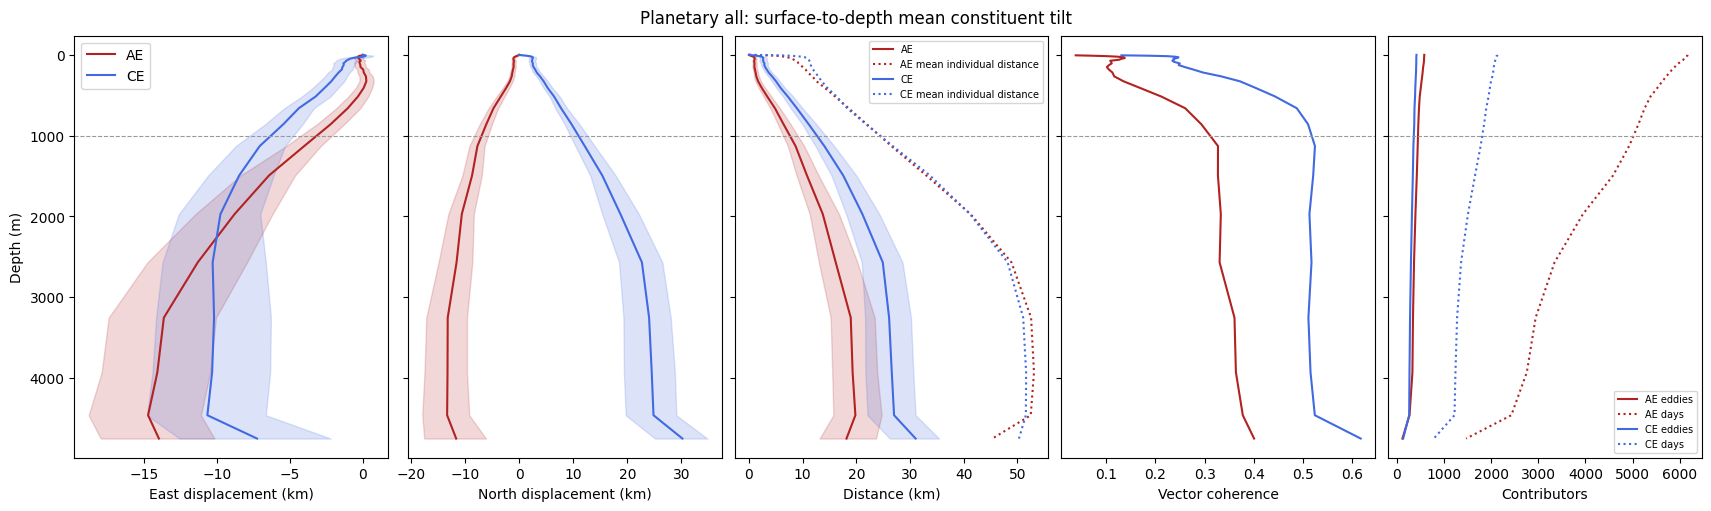

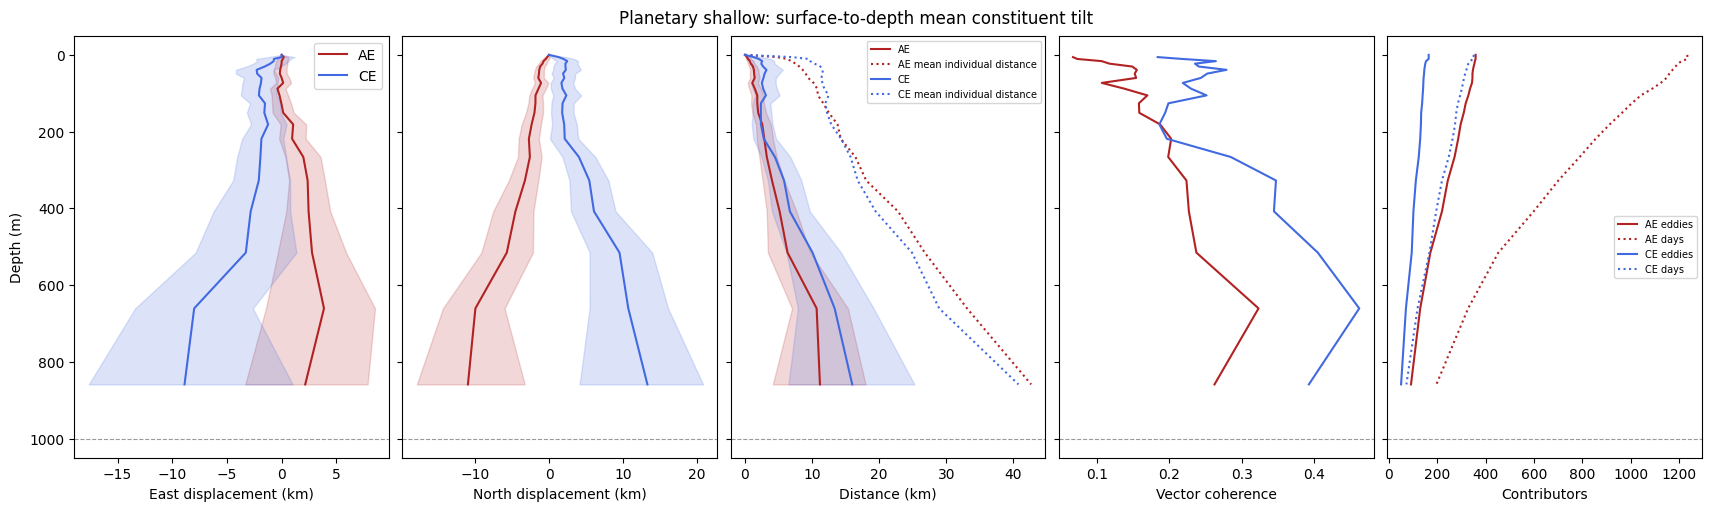

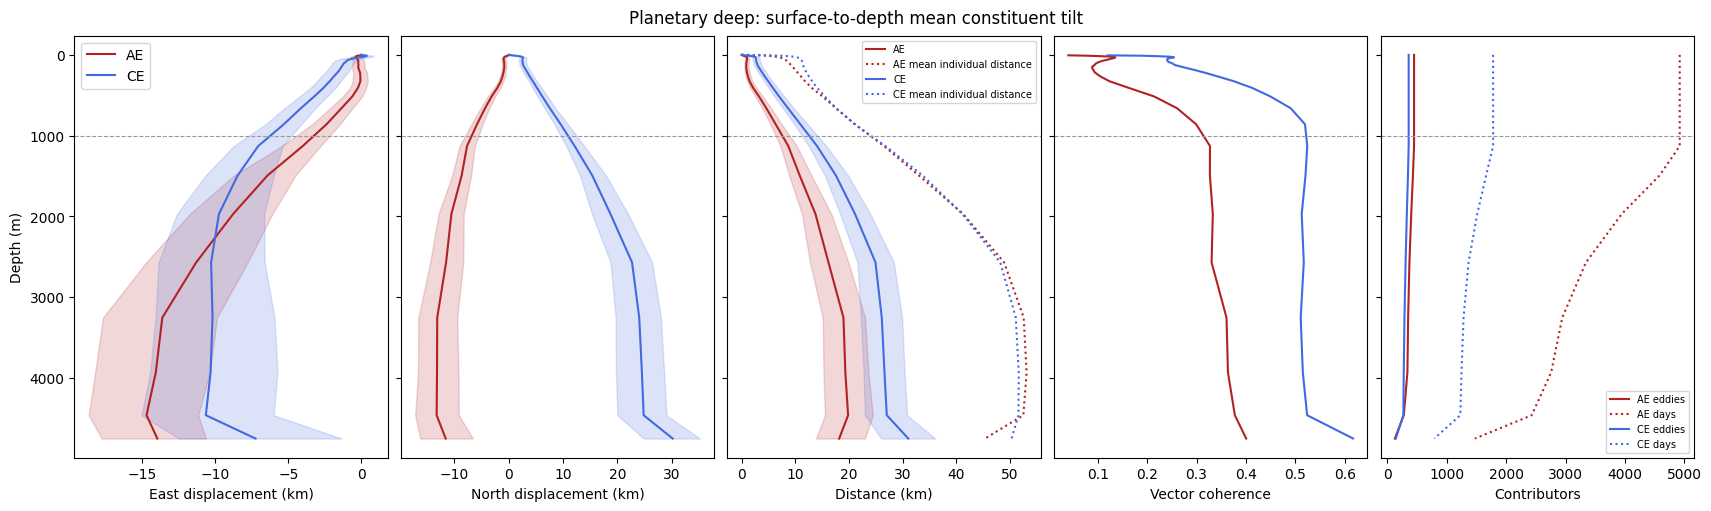

In [4]:
COLORS = {'AE':'firebrick','CE':'royalblue'}
for cohort in ['all','shallow','deep']:
    fig,axs=plt.subplots(1,5,figsize=(17,5),sharey=True,constrained_layout=True)
    for cyc in ['AE','CE']:
        if (cohort,cyc) not in results: continue
        s=results[cohort,cyc]['stats'].copy()
        ok=s.n_eddies.ge(MIN_PLOT_EDDIES)
        for ax,col,lo,hi in [(axs[0],'mean_east','mean_east_ci_low','mean_east_ci_high'),
                             (axs[1],'mean_north','mean_north_ci_low','mean_north_ci_high'),
                             (axs[2],'distance_km','distance_ci_low','distance_ci_high')]:
            ax.plot(s[col].where(ok),s.Depth,color=COLORS[cyc],label=cyc)
            ax.fill_betweenx(s.Depth,s[lo].where(ok),s[hi].where(ok),color=COLORS[cyc],alpha=.18)
        axs[2].plot(s.mean_member_distance_km.where(ok),s.Depth,':',color=COLORS[cyc],label=f'{cyc} mean individual distance')
        axs[3].plot(s.coherence.where(ok),s.Depth,color=COLORS[cyc])
        axs[4].plot(s.n_eddies,s.Depth,color=COLORS[cyc],label=f'{cyc} eddies')
        axs[4].plot(s.n_eddy_days,s.Depth,':',color=COLORS[cyc],label=f'{cyc} days')
    for ax,label in zip(axs,['East displacement (km)','North displacement (km)','Distance (km)','Vector coherence','Contributors']):
        ax.set_xlabel(label); ax.axhline(SPLIT_DEPTH_M,color='.6',ls='--',lw=.8)
    axs[0].set_ylabel('Depth (m)'); axs[0].invert_yaxis()
    axs[0].legend();axs[2].legend(fontsize=7);axs[4].legend(fontsize=7)
    fig.suptitle(f'Planetary {cohort}: surface-to-depth mean constituent tilt')
    plt.show()


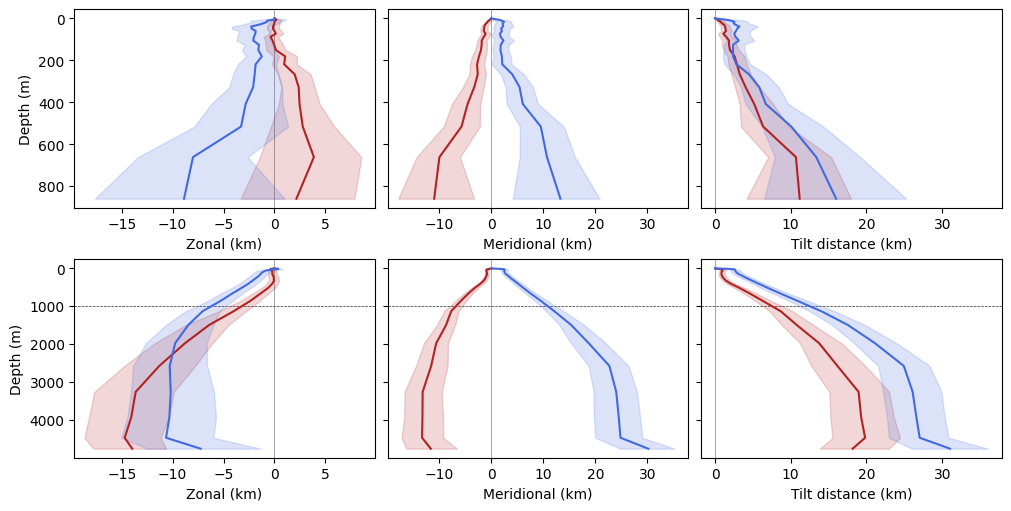

In [52]:
fig,axs=plt.subplots(2,3,figsize=(10,5),sharey=False,constrained_layout=True)
for c, cohort in enumerate(['shallow','deep']):
    for cyc in ['AE','CE']:
        if (cohort,cyc) not in results: continue
        s=results[cohort,cyc]['stats'].copy()
        ok=s.n_eddies.ge(MIN_PLOT_EDDIES)
        for r, (ax,col,lo,hi) in enumerate([(axs[c,0],'mean_east','mean_east_ci_low','mean_east_ci_high'),
                             (axs[c,1],'mean_north','mean_north_ci_low','mean_north_ci_high'),
                             (axs[c,2],'distance_km','distance_ci_low','distance_ci_high')]):
            ax.plot(s[col].where(ok),s.Depth,color=COLORS[cyc],label=cyc)
            ax.fill_betweenx(s.Depth,s[lo].where(ok),s[hi].where(ok),color=COLORS[cyc],alpha=.18)
            if r!=0: ax.set_yticklabels([])
            if c==1: ax.axhline(1000,color='k', zorder=0, alpha=.5, ls='--',lw=.5)
            ax.set_ylabel('Depth (m)' if r == 0 else ''); 
            if r == 0:
                ax.set_xlabel('Zonal (km)')
            if r == 1:
                ax.set_xlabel('Meridional (km)')
            if r == 2:
                ax.set_xlabel('Tilt distance (km)')
for j in range(3):
    xlim = (min(ax.get_xlim()[0] for ax in axs[:,j]),
            max(ax.get_xlim()[1] for ax in axs[:,j]))
    [ax.set_xlim(xlim) for ax in axs[:,j]]
for ax in axs.flat: ax.invert_yaxis(); ax.axvline(0,lw=.5,color='k', zorder=0, alpha=.5)


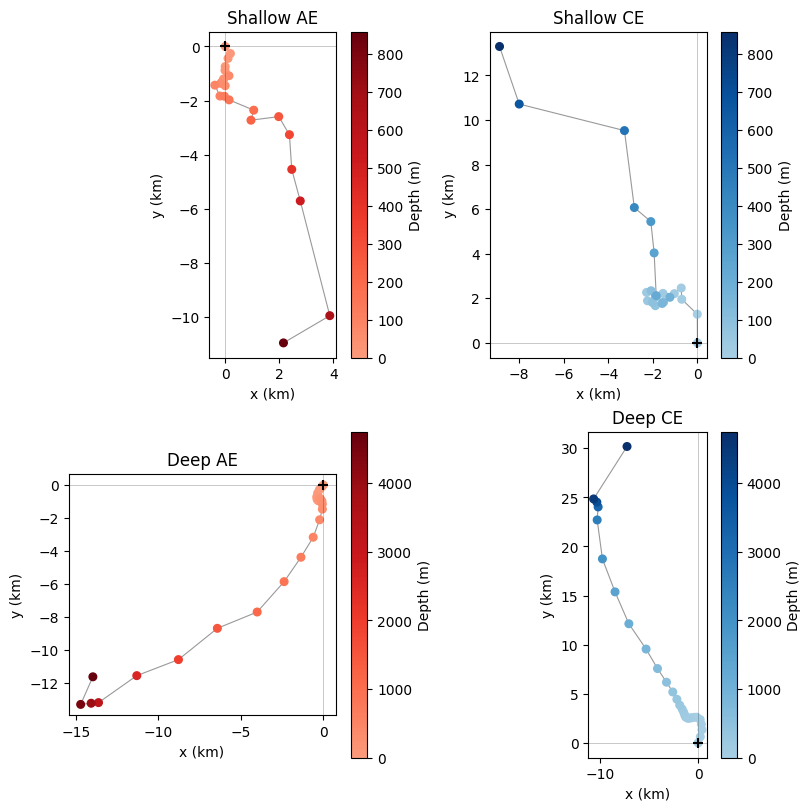

In [49]:
from matplotlib.colors import LinearSegmentedColormap

fig, axs = plt.subplots(2,2,figsize=(8,8),constrained_layout=True)

for i,cohort in enumerate(['shallow','deep']):
    for j,cyc in enumerate(['AE','CE']):
        ax=axs[i,j]
        if (cohort,cyc) not in results: continue

        s=results[cohort,cyc]['stats'].copy()
        s=s[s.n_eddies.ge(MIN_PLOT_EDDIES)].dropna(subset=['mean_east','mean_north','Depth'])
        # cmap=plt.cm.Reds[.45,.95] if cyc=='AE' else plt.cm.Blues
        base = plt.cm.Reds if cyc == 'AE' else plt.cm.Blues
        cmap = LinearSegmentedColormap.from_list(
            f'{cyc}_cmap', base(np.linspace(.35, 1, 256))
        )
        norm=plt.Normalize(s.Depth.min(),s.Depth.max())

        ax.plot(s.mean_east,s.mean_north,color='0.6',lw=.8,zorder=0)
        sc=ax.scatter(s.mean_east,s.mean_north,c=s.Depth,cmap=cmap,norm=norm,s=30)

        ax.scatter(0,0,c='k',marker='+',s=60)
        ax.axhline(0,color='k',lw=.5,alpha=.3)
        ax.axvline(0,color='k',lw=.5,alpha=.3)
        ax.set_aspect('equal')
        ax.set_title(f'{cohort.capitalize()} {cyc}')
        ax.set(xlabel='x (km)',ylabel='y (km)')
        fig.colorbar(sc,ax=ax,label='Depth (m)')

plt.show()

## Horizontal velocity composites in model-grid coordinates
These maps retain the original model-grid velocities and centre coordinates. Geographic zonal/meridional sections are added below, rotating both sampling locations and velocity components.


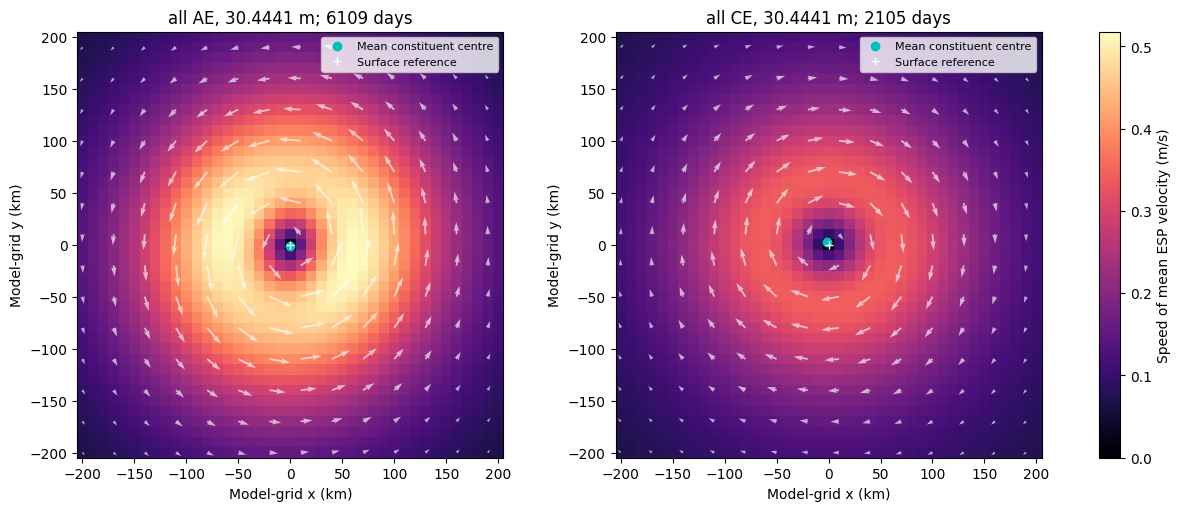

In [54]:
MAP_COHORT = 'all'
MAP_DEPTH_M = np.abs(grid.z_r[150,150,5])

fields=[]
for cyc in ['AE','CE']:
    r=results.get((MAP_COHORT,cyc))
    if r is not None and 'u' in r and MAP_DEPTH_M in r['depths']:
        k=int(np.flatnonzero(r['depths']==MAP_DEPTH_M)[0])
        speed=np.hypot(r['u'][...,k],r['v'][...,k])
        if np.isfinite(speed).any(): fields.append((cyc,r,k,speed))

if fields:
    fig,axs=plt.subplots(1,len(fields),figsize=(6*len(fields),5),
                         squeeze=False,constrained_layout=True)
    vmax=max(np.nanmax(f) for _,_,_,f in fields)

    for ax,(cyc,r,k,speed) in zip(axs.flat,fields):
        im=ax.pcolormesh(X,Y,speed,cmap='magma',vmin=0,vmax=vmax,shading='auto')

        step=max(1,len(X)//11)
        sl=(slice(None,None,step),slice(None,None,step))
        ax.quiver(X[sl],Y[sl],r['u'][...,k][sl],r['v'][...,k][sl],
                  color='white',alpha=.65,
                  scale=max(vmax,1e-12)*15,scale_units='width')

        m=r['members'].loc[lambda d:d.Depth.eq(MAP_DEPTH_M)]
        ax.plot(m.xc.mean(),m.yc.mean(),'co',label='Mean constituent centre')
        ax.plot(0,0,'w+',label='Surface reference')

        ax.set(aspect='equal',
               xlabel='Model-grid x (km)',
               ylabel='Model-grid y (km)',
               title=f'{MAP_COHORT} {cyc}, {MAP_DEPTH_M:g} m; {len(m)} days')
        ax.legend(fontsize=8)

    fig.colorbar(im,ax=list(axs.flat),label='Speed of mean ESP velocity (m/s)')
    plt.show()

else:
    print('No velocity composite at that exact depth/cohort; check support or enable RUN_VELOCITY_COMPOSITES.')

## Composite comparison summary
The following summary and structural plots compare the shallow and deep AE/CE populations already computed above.


In [ ]:
comparison_sets = {'Planetary': results}


### Tilt distance: comparable reference and deepest supported level
`tilt_summary` reports the **length of the mean constituent displacement vector**, with its pointwise eddy-bootstrap confidence interval and depth-specific support. It also retains the mean individual displacement length as a separate quantity.

For the first comparison, choose one **shared exact fitted depth** across all available shallow/deep AE/CE groups (including shelf groups in the topographic notebook). The closest common level to `SUMMARY_TARGET_DEPTH_M` is used only within `SUMMARY_DEPTH_TOLERANCE_M`; its actual depth is shown. If none exists, the comparison is explicitly unavailable. There is no depth interpolation or separate nearest-depth choice per group.

The second comparison reports each group's deepest level with at least `MIN_PLOT_EDDIES` contributors. These endpoint distances describe their own sampled extent; they are not distances at equal depths, nor a mean of each eddy's bottom displacement. Changing membership with depth and fit truncation still apply. Confidence intervals are pointwise, not simultaneous bands or uncertainty in the chosen endpoint.


In [ ]:
SUMMARY_TARGET_DEPTH_M = 500.0
SUMMARY_DEPTH_TOLERANCE_M = 100.0
tilt_summary = ccomp.tilt_summary(comparison_sets,
    target_depth=SUMMARY_TARGET_DEPTH_M, depth_tolerance=SUMMARY_DEPTH_TOLERANCE_M,
    min_eddies=MIN_PLOT_EDDIES)
with pd.option_context('display.max_rows',None,'display.max_columns',None):
    display(tilt_summary.round(3))
ccomp.plot_tilt_summary(tilt_summary)
plt.show()


### Composite ESP structure with depth: inner w, outer Omega and Rc
Fit **each composite velocity field itself**, using the same DOPPIO inner-core + ESP outer-core routines as `composite_breakdown`. These are not averages of constituent ESP parameters. `w` is the inner fit's vorticity estimate, `Omega` is the outer ESP rotation parameter (both s⁻¹), and `Rc` is km. The full fitted field's central vorticity `w_full_fit = Omega × trace(Q)` is also available in `composite_esp_fits`.

Only levels meeting the minimum contributing-eddy count are eligible. Failed fits retain their reason and leave gaps; no fit is interpolated. The fourth panel shows local vector R² to help distinguish a representative ESP fit from a poor one. These parameter curves have no fitted-parameter confidence bands: constituent-centre bootstrap intervals do not measure uncertainty in an ESP refit. Coordinates remain in the composite's native frame; scalar w, Omega and Rc are rotation invariant.

`RUN_COMPOSITE_FITS=False` skips this step; velocity reconstruction must be enabled to fit. The fits below are separate from the mean-constituent tilt estimator.


In [ ]:
RUN_COMPOSITE_FITS = True
FIT_TRANSECT_RADIUS_KM = 30.0
FIT_RHO_MIN_KM, FIT_RHO_MAX_KM = 30.0, 200.0
FIT_OUT_CORE_FACTOR = 1.75
FIT_MAX_CENTRE_JUMP_KM = 100.0
FIT_MIN_CELL_DAYS = 1
composite_esp_fits = pd.DataFrame()
composite_fit_audit = pd.DataFrame()
if RUN_COMPOSITE_FITS:
    composite_esp_fits, composite_fit_audit = ccomp.fit_collections(
        comparison_sets,X,Y,esp,min_eddies=MIN_PLOT_EDDIES,
        transect_radius_km=FIT_TRANSECT_RADIUS_KM,
        rho_min_km=FIT_RHO_MIN_KM,rho_max_km=FIT_RHO_MAX_KM,
        out_core_fac=FIT_OUT_CORE_FACTOR,max_jump_km=FIT_MAX_CENTRE_JUMP_KM,
        min_cell_days=FIT_MIN_CELL_DAYS)
    display(composite_fit_audit)
    if not composite_esp_fits.empty:
        display(composite_esp_fits)
        display(composite_esp_fits.loc[~composite_esp_fits.fit_ok,
            ['population','cohort','Cyc','Depth','reason']])
        for population in composite_esp_fits.population.unique():
            ccomp.plot_fit_profiles(composite_esp_fits,population)
            plt.show()
else:
    print('Composite ESP fits skipped.')


### Vertical velocity sections through the surface centre
Each row shows one polarity. The first panel is the x-directed cut through y = 0, coloured by transverse (y) velocity; the second is the y-directed cut through x = 0, coloured by x velocity. This shows both sides of the rotating core and the zero-velocity structure, complementing the horizontal speed maps. Colours share a symmetric m/s scale within each AE/CE comparison; black contours mark zero velocity.

Here x is geographic east and y is north: **zonal cuts show northward velocity; meridional cuts show eastward velocity**. The planetary arrays are originally in model-grid axes, so both sampling locations and velocity components are rotated using `grid.angle`. Bilinear interpolation is horizontal only; depth levels are not interpolated.

Cuts remain anchored at the surface centre; they do not follow the moving deeper centre. A strongly tilted core can therefore move out of a cut. Unsupported depths/cells stay blank. Use `SECTION_COHORTS` and `SECTION_POPULATIONS` to control the displayed comparisons.


In [ ]:
SECTION_POPULATIONS = ['Planetary']
SECTION_COHORTS = ['shallow','deep']
for population in SECTION_POPULATIONS:
    for cohort in SECTION_COHORTS:
        fig = ccomp.plot_sections(comparison_sets[population],X,Y,population,cohort,
            rotation_rad=grid.angle,frame='geographic',
            min_eddies=MIN_PLOT_EDDIES)
        if fig is not None: plt.show()
        else: print(population,cohort,': no reconstructed velocity fields')


### Optional comparison-table export
The summary, full ESP fits and fit-status table remain available in memory. These exports overwrite only the comparison tables below; existing constituent and profile tables are unchanged.


In [ ]:
SAVE_COMPARISON_TABLES = False
if SAVE_COMPARISON_TABLES:
    out=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/planetary_composite_tilt')
    out.mkdir(parents=True,exist_ok=True)
    tilt_summary.to_csv(out/'tilt_summary.csv',index=False)
    composite_esp_fits.to_csv(out/'composite_esp_fits.csv',index=False)
    composite_fit_audit.to_csv(out/'composite_fit_audit.csv',index=False)
    (out/'comparison_settings.json').write_text(json.dumps(dict(
        summary_target_depth_m=SUMMARY_TARGET_DEPTH_M,summary_tolerance_m=SUMMARY_DEPTH_TOLERANCE_M,
        minimum_eddies=MIN_PLOT_EDDIES,split_depth_m=SPLIT_DEPTH_M,
        shelf_lon=None,grid_angle_rad=float(grid.angle),
        fit_transect_km=FIT_TRANSECT_RADIUS_KM,fit_rho_min_km=FIT_RHO_MIN_KM,
        fit_rho_max_km=FIT_RHO_MAX_KM,fit_out_core_factor=FIT_OUT_CORE_FACTOR,
        fit_max_jump_km=FIT_MAX_CENTRE_JUMP_KM,fit_min_cell_days=FIT_MIN_CELL_DAYS),indent=2))
    print(out)
